# Voteview over MCP — tools, schemas and example calls

Voteview has **no tools of its own**, and that is the interesting part. It is
served entirely by the generic stored-series tools that WONDER and NVSR use, so
adding it needed no server work at all — a builder, a `.jsonl`, and the same
two loaders.

Compare CDC, which needed `cdc_series_data`, `cdc_dataset_facets` and
`cdc_dataset_columns` because Socrata is a live API over heterogeneous
datasets. Anything reduced to stored series arrives here for free.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append("../")
sys.path.append("../../")

from matplotlib import pyplot
from lib import config
from utils import (
    list_mcp_tools, show_tool_schema,
    list_series, get_series, search_catalog,
    plot_series, plot_group,
)

pyplot.style.use(config.glyfish_style)

## 1. The tools that serve it

In [2]:
await list_mcp_tools(prefix=("timeseries_source_", "series_catalog_"))

timeseries_source_list: List stored time series held in meida's database — sources that cannot be fetched per request, currently CDC WONDER (cause-of-death rates: alcohol, drug, suicide, homicide, firearm, chronic liver, deaths of despair) and CDC NVSR (life expectancy / life tables). Returns identity and coverage without observations, as {'series': [...]}. Optional 'source' filters to cdc_wonder or cdc_nvsr.
timeseries_source_data: Return one stored time series in full, with its observations, from meida's database (CDC WONDER cause-of-death rates, CDC NVSR life expectancy). 'source' is cdc_wonder or cdc_nvsr and 'native_id' is the series identifier from timeseries_source_list. Pass 'frequency' only if an id is ambiguous. Observation values are strings — cast as needed.
timeseries_source_stale: List stored series that are due for an update — past their refresh horizon. These sources have no live API (CDC WONDER is throttled behind a bot filter; NVSR is a manual annual download), so ref

## 2. Schemas

`timeseries_source_data` takes a `source` and a `native_id` — nothing
Voteview-specific. The same call shape retrieves an NVSR life-expectancy series.

In [3]:
_ = await show_tool_schema("timeseries_source_data")

timeseries_source_data
  Return one stored time series in full, with its observations, from meida's database (CDC WONDER cause-of-death rates, CDC NVSR life expectancy). 'source' is cdc_wonder or cdc_nvsr and 'native_id' is the series identifier from timeseries_source_list. Pass 'frequency' only if an id is ambiguous. Observation values are strings — cast as needed.

  source               string     required  
  native_id            string     required  
  frequency            any        optional  


## 3. What is stored

In [4]:
for s in sorted(await list_series(), key=lambda x: x["native_id"]):
    print(f"  {s['native_id']:48s} {s['observation_count']:3d} obs  "
          f"{s['observation_start'][:4]}-{s['observation_end'][:4]}  "
          f"{s['units']:8s} stale={s['stale']}")


  voteview/effective_parties/house                 119 obs  1789-2025  parties  stale=False
  voteview/effective_parties/senate                119 obs  1789-2025  parties  stale=False
  voteview/median_gap/house                         85 obs  1857-2025  dim1     stale=False
  voteview/median_gap/senate                        79 obs  1857-2025  dim1     stale=False
  voteview/moderate_bloc/house                      85 obs  1857-2025  members  stale=False
  voteview/moderate_bloc/senate                     79 obs  1857-2025  members  stale=False
  voteview/party_predicts_position/house           110 obs  1789-2025  ratio    stale=False
  voteview/party_predicts_position/senate          104 obs  1789-2025  ratio    stale=False


Eight series: four measures across House and Senate. The two spans differ for
a reason — `party_predicts_position` and `effective_parties` never name a
party, so they reach 1789, while `median_gap` and `moderate_bloc` need both
Democrats and Republicans and so begin at the 35th Congress in 1857.

## 4. Finding one through the catalog

Facets are `measure` and `chamber`.

In [5]:
for entry in sorted(await search_catalog(chamber="house"), key=lambda e: e["series_id"]):
    print(f"  {entry['series_id']:48s} {entry['observation_start']}..{entry['observation_end']}")
    print(f"      {entry['description'][:96]}")


  voteview/effective_parties/house                 1789-01-01..2025-01-01
      Laakso-Taagepera index, 1 / sum(seat share squared).
  voteview/median_gap/house                        1857-01-01..2025-01-01
      Republican median minus Democratic median on DW-NOMINATE dim1. Requires >= 20 members of each, s
  voteview/moderate_bloc/house                     1857-01-01..2025-01-01
      Count of Democrats at or right of the most liberal Republican, plus Republicans at or left of th
  voteview/party_predicts_position/house           1789-01-01..2025-01-01
      Distance between the two largest parties' medians on DW-NOMINATE dim1, over the membership-weigh


## 5. Fetch and plot

The measure the whole exercise turns on: how much party membership predicts a
member's position.

How much party membership predicts ideology — US House
  110 obs | ratio | due 2026-10-13


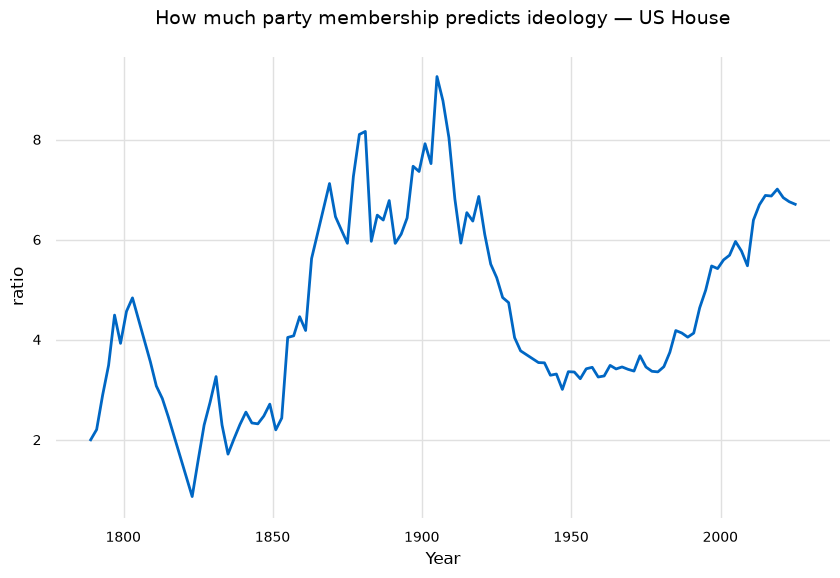

In [6]:
predicts = await get_series("voteview/party_predicts_position/house")
print(f"{predicts['title']}\n  {predicts['observation_count']} obs | "
      f"{predicts['units']} | due {str(predicts['expires_at'])[:10]}")
plot_series(predicts)

The gaps are Congresses where the second party held under 25% of the chamber —
the measure declines to answer rather than compare a 163-member median against
a 35-member remnant. 1817–1823 is the Era of Good Feelings sitting in that gap.

## 6. The two measures that need each other

A dominant party is not an agreeable one. 1807 had the same 82% supermajority
as 1821 and four times the separation, so neither number means much alone.

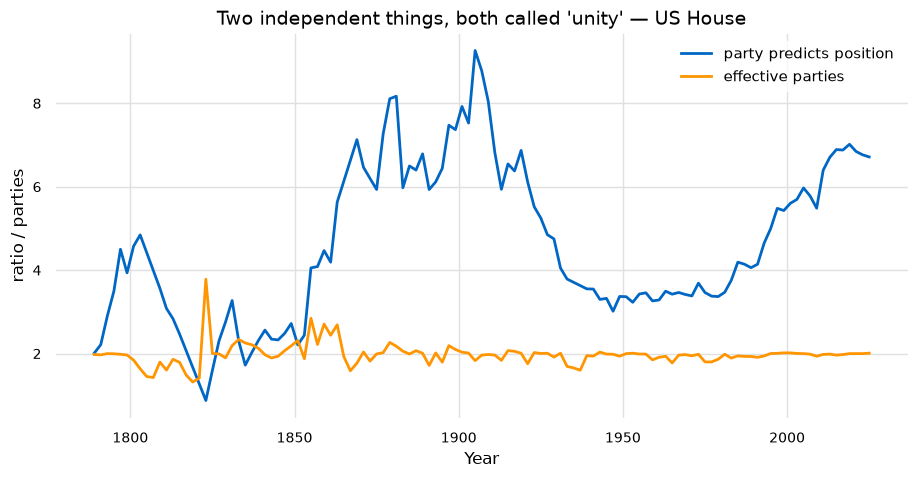

In [7]:
ratio = await get_series("voteview/party_predicts_position/house")
parties = await get_series("voteview/effective_parties/house")
plot_group([ratio, parties], ["party predicts position", "effective parties"],
           title="Two independent things, both called 'unity' — US House",
           ylabel="ratio / parties")


## 7. The conventional pair

`median_gap` is what published work reports; `moderate_bloc` counts who is left
in between. They are not redundant — the bloc reached zero in 2007 and stayed
there while the gap kept climbing.

In [8]:
gap = await get_series("voteview/median_gap/house")
bloc = await get_series("voteview/moderate_bloc/house")
by_year = {int(o["date"][:4]): o["value"] for o in gap["observations"]}
bloc_by_year = {int(o["date"][:4]): o["value"] for o in bloc["observations"]}
print("  year   median gap   moderate bloc")
for year in (1947, 1963, 1987, 2007, 2025):
    print(f"  {year}   {by_year.get(year, '-'):>10}   {bloc_by_year.get(year, '-'):>13}")


  year   median gap   moderate bloc
  1947       0.4975             107
  1963       0.5775              88
  1987        0.666              42
  2007        0.805               0
  2025       0.9255               0


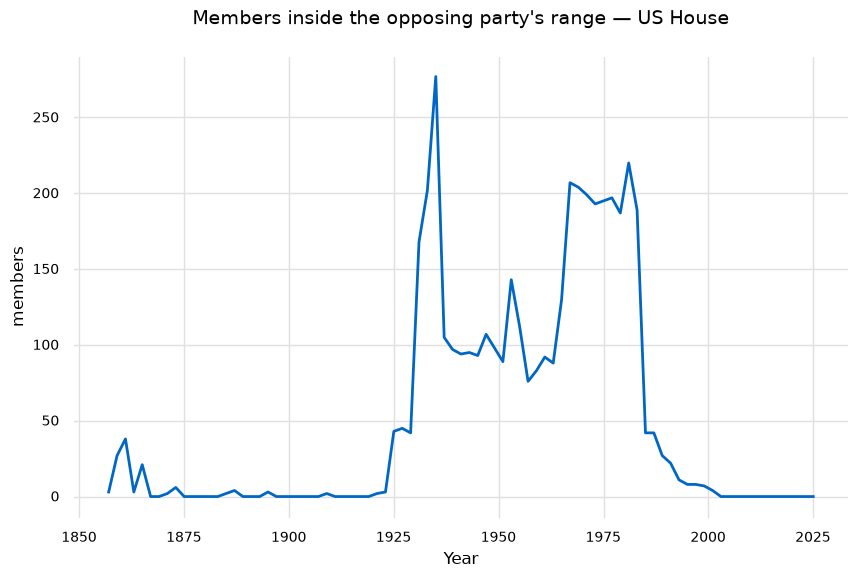

In [9]:
plot_series(bloc, title="Members inside the opposing party's range — US House")

Zero from 2007 on. The gap over the same stretch went 0.805 → 0.925, so the
parties kept separating after there was already nobody between them.

See [`client.ipynb`](client.ipynb) for the same numbers computed from the CSV,
where the reduction is visible.